In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Load the data (same as before)
data_path = mne.datasets.sample.data_path()
raw_fif_path = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(raw_fif_path, preload=True)

# Pick only EEG channels for this tutorial
raw.pick('eeg')

print(f"Loaded {len(raw.ch_names)} EEG channels")
print(f"Sampling rate: {raw.info['sfreq']} Hz")

Opening raw data file /Users/aleksandraszymanska/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Loaded 60 EEG channels
Sampling rate: 600.614990234375 Hz


Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


/Users/aleksandraszymanska/Desktop/eeg-pipeline/venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


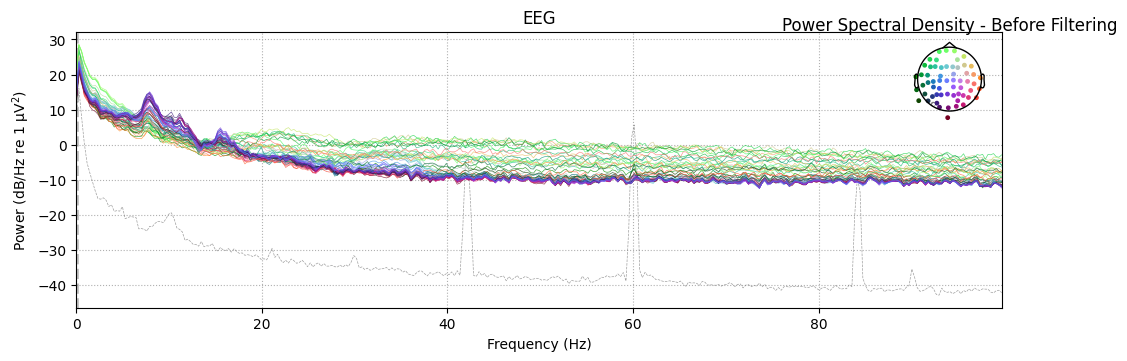

In [2]:
# Compute the Power Spectral Density (PSD)
fig = raw.compute_psd(fmax=100).plot()
plt.title("Power Spectral Density - Before Filtering")
plt.show()

In [3]:
# Make a copy (keep original for comparison)
raw_filtered = raw.copy()

# Bandpass filter: keep only 0.1 - 40 Hz
raw_filtered.filter(l_freq=0.1, h_freq=40.0)

print("Bandpass filter applied: 0.1 - 40 Hz")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 19821 samples (33.001 s)

Bandpass filter applied: 0.1 - 40 Hz


Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).
Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


/var/folders/hy/4bfcl6wj5x9blcjd8wnvrhyr0000gn/T/ipykernel_69978/175073282.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


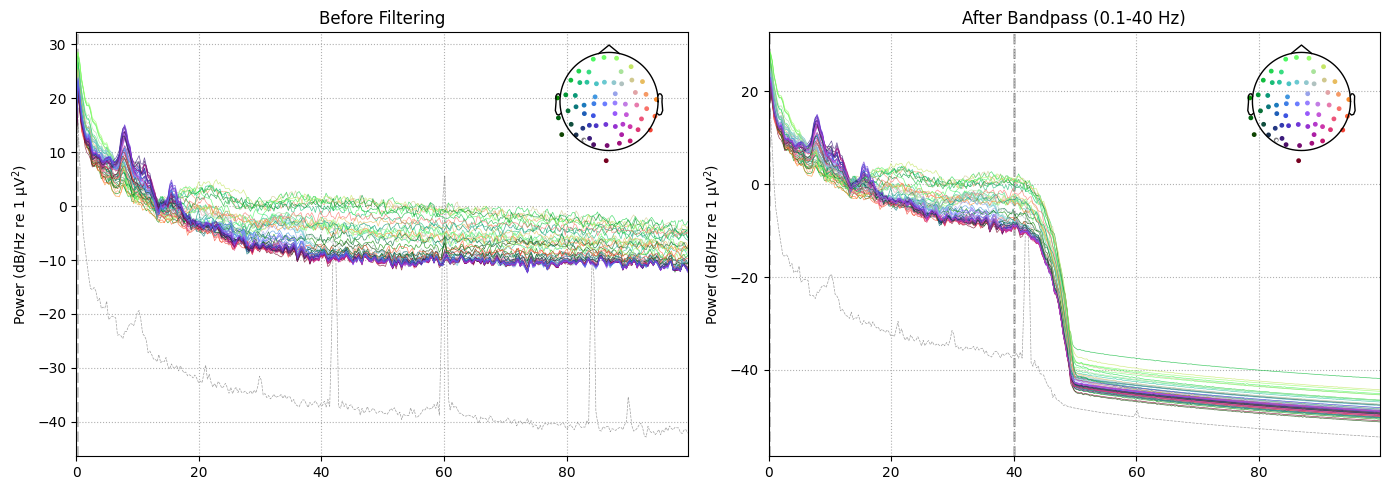

In [4]:
# Plot PSDs side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before filtering
raw.compute_psd(fmax=100).plot(axes=axes[0], show=False)
axes[0].set_title("Before Filtering")

# After filtering
raw_filtered.compute_psd(fmax=100).plot(axes=axes[1], show=False)
axes[1].set_title("After Bandpass (0.1-40 Hz)")

plt.tight_layout()
plt.show()

Plotting channel: EEG 001


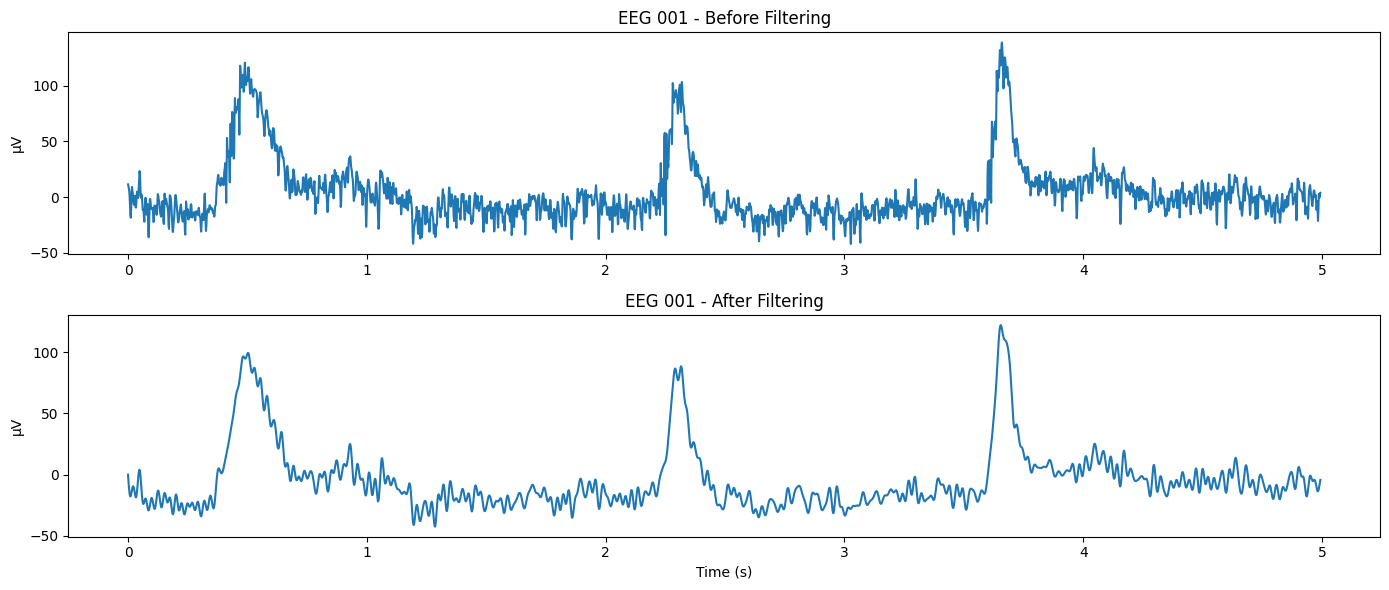

In [7]:
# Get the first available EEG channel name
channel = raw_filtered.ch_names[0]
print(f"Plotting channel: {channel}")

# Get data - use sampling rate to calculate samples for 5 seconds
sfreq = int(raw_filtered.info['sfreq'])
n_samples = sfreq * 5  # 5 seconds

# Get time and data
times = raw_filtered.times[:n_samples]
data_before = raw.get_data(picks=[channel])[0, :n_samples] * 1e6
data_after = raw_filtered.get_data(picks=[channel])[0, :n_samples] * 1e6

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(times, data_before)
axes[0].set_title(f"{channel} - Before Filtering")
axes[0].set_ylabel("µV")

axes[1].plot(times, data_after)
axes[1].set_title(f"{channel} - After Filtering")
axes[1].set_ylabel("µV")
axes[1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()